№1 (2 балла)<br/>
Изучите материал https://cloud.mail.ru/public/S4Pu/zPnKHX7qT. Выполните задания из
файла https://cloud.mail.ru/public/KtLN/hjdfs92YL. 

№2 (2 балла)<br/>
Выполните задания из файла https://cloud.mail.ru/public/CDUu/PZPV4W8FX. Данные
скачайте отсюда https://cloud.mail.ru/public/ZyCV/8w6p1i19o. 

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

1. Загрузите данные в DataFrame, используя функцию read_csv

In [12]:
df = pd.read_csv('house_price.csv')

2. Сколько строк и столбцов в данных? Есть ли пропуски? Используйте метод


In [13]:
df.shape

(1460, 82)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

3. Для выполнения задания в наборе данных необходимо оставить только
числовые признаки. Для этого можно использовать следующий программный
код (а можно придумать свой):

In [15]:
numeric_dtypes = ['int64', 'float64']
numerics = [c for c in df.columns if df[c].dtype in numeric_dtypes]

In [16]:
df_num = df[numerics]
print('Перед dropna:', df_num.shape)
print(df_num.isna().sum().sort_values(ascending=False).head(10))

Перед dropna: (1460, 39)
Unnamed: 81    1460
LotFrontage     259
GarageYrBlt      81
MasVnrArea        8
LotArea           0
Id                0
MSSubClass        0
YearBuilt         0
OverallCond       0
OverallQual       0
dtype: int64


4. Удалите столбец Id и пропущенные значения.

In [17]:
del df_num['Id']
del df_num['Unnamed: 81'] # Полностью пустой столбец


In [18]:
df_num = df_num.dropna()
print('После dropna:', df_num.shape)
df_num.info()

После dropna: (1121, 37)
<class 'pandas.core.frame.DataFrame'>
Index: 1121 entries, 0 to 1459
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1121 non-null   int64  
 1   LotFrontage    1121 non-null   float64
 2   LotArea        1121 non-null   int64  
 3   OverallQual    1121 non-null   int64  
 4   OverallCond    1121 non-null   int64  
 5   YearBuilt      1121 non-null   int64  
 6   YearRemodAdd   1121 non-null   int64  
 7   MasVnrArea     1121 non-null   float64
 8   BsmtFinSF1     1121 non-null   int64  
 9   BsmtFinSF2     1121 non-null   int64  
 10  BsmtUnfSF      1121 non-null   int64  
 11  TotalBsmtSF    1121 non-null   int64  
 12  1stFlrSF       1121 non-null   int64  
 13  2ndFlrSF       1121 non-null   int64  
 14  LowQualFinSF   1121 non-null   int64  
 15  GrLivArea      1121 non-null   int64  
 16  BsmtFullBath   1121 non-null   int64  
 17  BsmtHalfBath   1121 non-null   i

5. Разделите набор данных на входные данные X (все столбцы кроме SalePrice)
и ответы y (столбец SalePrice).


In [19]:
X = df_num.drop('SalePrice', axis = 1)
y = df_num['SalePrice']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Первые 5 строк X:')
print(X.head())
print('Первые 5 значений y:')
print(y.head())

X shape: (1121, 36)
y shape: (1121,)
Первые 5 строк X:
   MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0          60         65.0     8450            7            5       2003   
1          20         80.0     9600            6            8       1976   
2          60         68.0    11250            7            5       2001   
3          70         60.0     9550            7            5       1915   
4          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  GarageArea  \
0          2003       196.0         706           0  ...         548   
1          1976         0.0         978           0  ...         460   
2          2002       162.0         486           0  ...         608   
3          1970         0.0         216           0  ...         642   
4          2000       350.0         655           0  ...         836   

   WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  S

6. Разделите данные на обучающую и тестовую выборки

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

7. Обучите модель LassoCV (установите значение гиперпараметра cv
самостоятельно). Оцените качество полученной модели. Посмотрите на
коэффициенты модели. Есть ли коэффициенты равные 0? Что это означает?
Сделайте выводы.


In [22]:
lasso5 = LassoCV(cv=5) # cv=5 за пример

In [ ]:
"""
Это означает, что для подбора alpha будет 
использоваться 5-блочная перекрестная проверка.
"""

In [23]:
 # Обучаем модель
lasso5.fit(X_train, y_train)
# Оцениваем качество
lasso5.score(X_test, y_test)
# Значения коэффициентов 
lasso5.coef_ 

array([ -0.        ,   0.        ,   0.44584531,   0.        ,
         0.        , 366.90662176, 191.50797121,  31.61891697,
         9.49435623,   0.39058882,  -0.        ,  25.43615783,
         3.23633319,   0.        ,  -0.        ,  57.59926723,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,  74.29640785,  34.30054188,
         0.        ,   0.        ,   0.        ,   0.        ,
        -0.        ,  -3.6500231 ,   0.        ,   0.        ])

In [24]:
lasso5.score(X_test, y_test)

0.7483887363346227

In [ ]:
"""
Значение R2 ≈ 0.75 показывает, что модель объясняет около 75% изменчивости цены SalePrice на тестовых данных
Это хороший результат, но линейная регрессия с L1-регуляризацией всё же не захватывает четверть разброса

LassoCV — это линейная регрессия с L1-штрафом, где гиперпараметр alpha автоматически подбирается 
через 5-блочную кросс-валидацию

L1-регуляризация "выталкивает" ненужные коэффициенты к нулю, создавая разреженную 
модель — многие веса становятся точно равными 0.

Ненулевые коэффициенты указывают на важные признаки, которые реально влияют на предсказание цены 
(положительно или отрицательно). Нулевые коэффициенты означают, что модель сочла эти признаки 
бесполезными — их эффект либо минимален, либо перекрывается другими. Таким образом, 
Lasso выполняет встроенный отбор признаков.
"""

№3 (2 балла)<br/>
Обучите модель линейной регрессии на данных согласно вашему варианту. Выведите
угловой коэффициент, точку пересечения с осью ординат и точность.


![image 145.png](<attachment:image 145.png>)
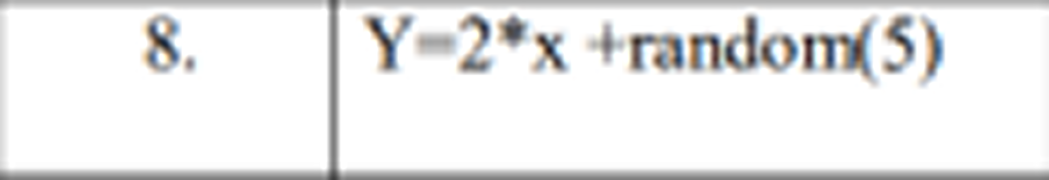

In [5]:
np.random.seed(0)                    # фиксируем генератор
x = np.arange(0, 21)                 # x = 0,1,...,20
noise = np.random.randint(0, 5, size=x.shape)  # random(5)
y = 2 * x + noise

In [6]:
X = x.reshape(-1, 1)         # превращаем в столбец признаков
model = LinearRegression()
model.fit(X, y)

k = model.coef_[0]           # угловой коэффициент
b = model.intercept_         # точка пересечения с осью Y
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)     # точность R^2

print("k =", k)
print("b =", b)
print("R^2 =", r2)

k = 1.9506493506493505
b = 2.3982683982683994
R^2 = 0.9852262901230076


№4 (3 балла)
Скачайте датасет https://cloud.mail.ru/public/SAi2/M1AzFm7BC, в котором по дням
записаны календарная информация и погодные условия, характеризующие
автоматизированные пункты проката велосипедов, а также число прокатов в этот день (это
значение необходимо предсказывать).
Для каждого дня проката известны следующие признаки (как они были указаны в источнике
данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень,
туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем
предсказывать)
Выполните следующие шаги:
1. Покажите на графиках, как целевой признак зависит от остальных. Каков характер
зависимости числа прокатов от месяца? Укажите один или два признака, от которых
число прокатов скорее всего зависит линейно.
2. Есть ли в данных похожие или дублирующие друг друга признаки? Как вы можете
показать их похожесть? Удалите такие признаки из датасета.
3. Разбейте данные на тренировочные и тестовые. Обучите модель линейной
регрессии. Выведите точность предсказания модели для тестовых данных. 

In [ ]:
df_bikes = pd.read_csv('bikes_rent.csv', sep=',')

df_bikes = df_bikes.drop(columns=['Unnamed: 13'])

cols_float = ['temp', 'atemp', 'hum', 'windspeed(mph)', 'windspeed(ms)', 'cnt']
for c in cols_float:
    df_bikes[c] = df_bikes[c].astype(str).str.replace(',', '.').astype(float)

df_bikes.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985.0
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801.0
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349.0
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562.0
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600.0


1. Покажите на графиках, как целевой признак зависит от остальных. Каков характер
зависимости числа прокатов от месяца? Укажите один или два признака, от которых
число прокатов скорее всего зависит линейно.

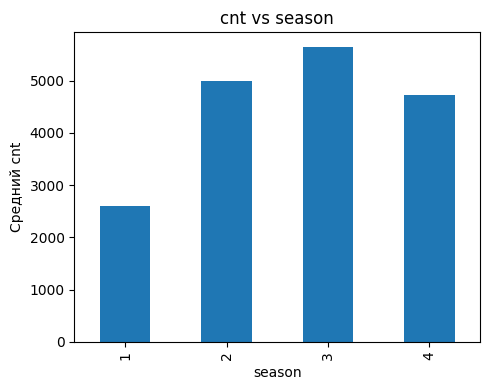

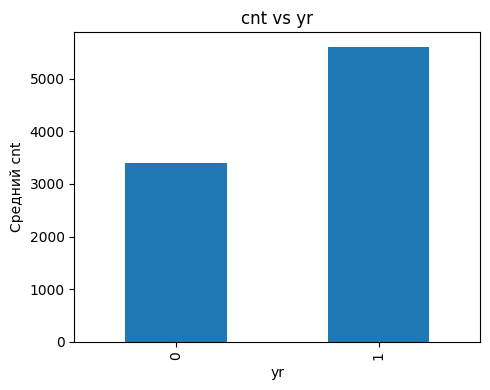

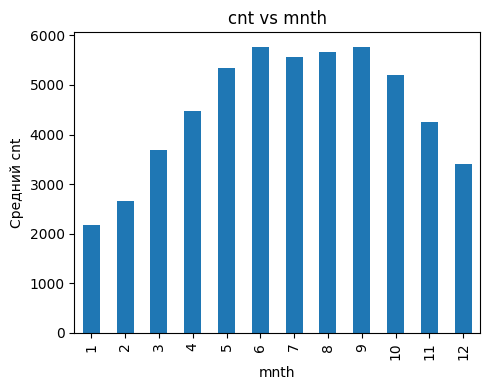

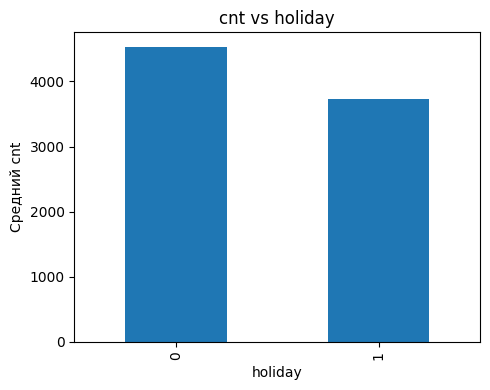

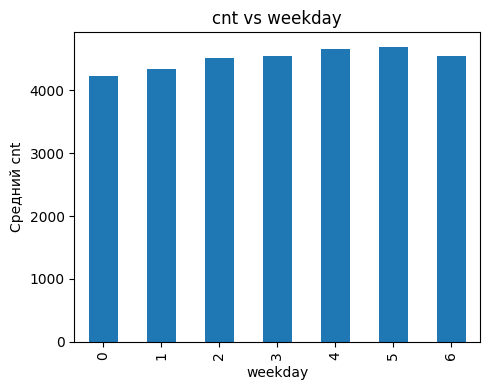

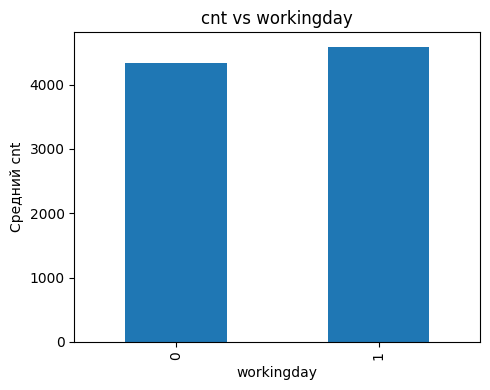

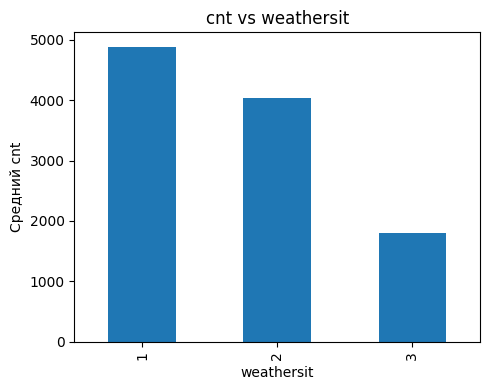

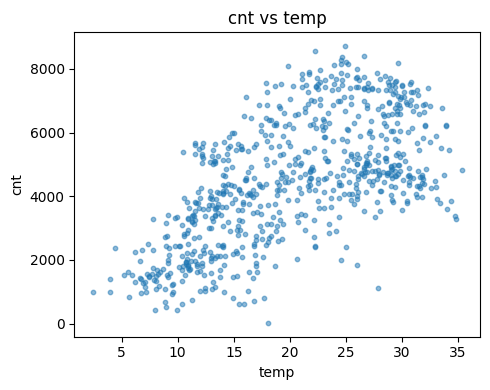

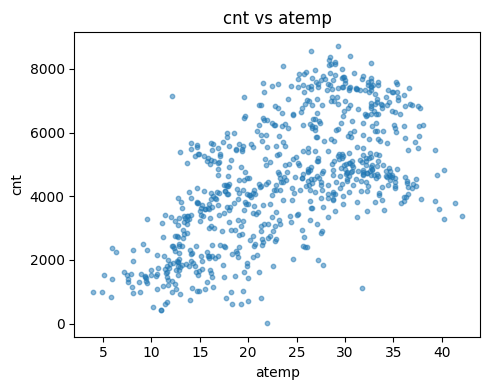

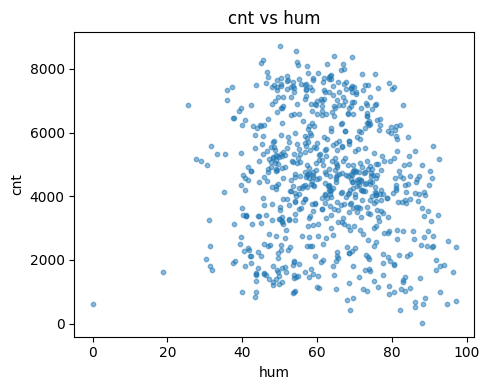

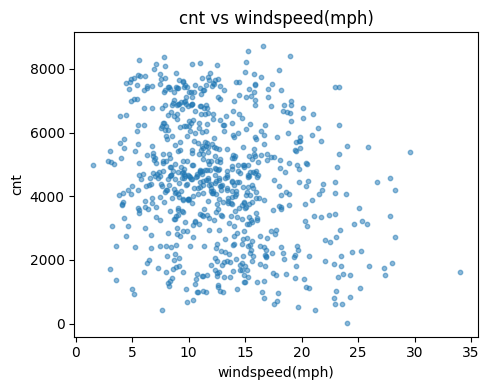

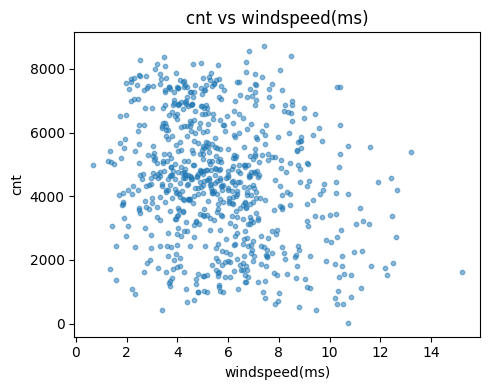

In [ ]:
target = 'cnt'
features = [c for c in df_bikes.columns if c != target]

for col in features:
    plt.figure(figsize=(5, 4))
    if df_bikes[col].nunique() <= 12:
        df_bikes.groupby(col)[target].mean().plot(kind='bar')
        plt.ylabel('Средний cnt')
    else:
        plt.scatter(df_bikes[col], df_bikes[target], s=10, alpha=0.5)
        plt.ylabel('cnt')
    plt.xlabel(col)
    plt.title(f'cnt vs {col}')
    plt.tight_layout()
    plt.show()

In [ ]:
"""
1. Характер зависимости числа прокатов от месяца (mnth)
Зависимость носит нелинейный, сезонный характер.
Низкий спрос зимой: В начале года (январь, февраль) и в конце года (декабрь) наблюдается минимальное количество прокатов.
Рост весной: С марта по май происходит резкий рост показателей.
Пик летом и в начале осени: Максимальные значения достигаются в теплые месяцы (июнь, июль, август, сентябрь). График напоминает «горку» или колокол.

2. Признаки с линейной зависимостью
Наиболее явная линейная зависимость прослеживается у температурных признаков:
temp (температура воздуха) — облако точек на диаграмме рассеяния вытянуто по диагонали вверх. 
С ростом температуры число прокатов растет практически линейно (до определенного предела, пока не становится слишком жарко).
atemp (ощущаемая температура) — показывает аналогичную картину, так как сильно коррелирует с обычной температурой.
Остальные признаки (например, hum — влажность, windspeed — скорость ветра) имеют вид бесформенного облака, что говорит о слабой или нелинейной связи.
"""

2. Есть ли в данных похожие или дублирующие друг друга признаки? Как вы можете
показать их похожесть? Удалите такие признаки из датасета.

In [9]:
corr = df_bikes[['temp', 'atemp', 'windspeed(mph)', 'windspeed(ms)', 'cnt']].corr()
print(corr)

                    temp     atemp  windspeed(mph)  windspeed(ms)       cnt
temp            1.000000  0.991702       -0.157944      -0.157944  0.627494
atemp           0.991702  1.000000       -0.183643      -0.183643  0.631066
windspeed(mph) -0.157944 -0.183643        1.000000       1.000000 -0.234545
windspeed(ms)  -0.157944 -0.183643        1.000000       1.000000 -0.234545
cnt             0.627494  0.631066       -0.234545      -0.234545  1.000000


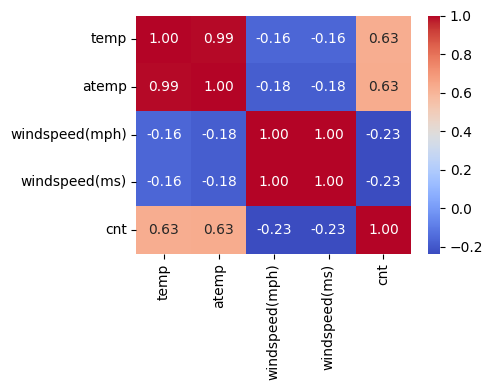

In [10]:
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

In [ ]:
"""
Да, в данных присутствуют пары признаков с очень высокой линейной зависимостью, что говорит о дублировании информации.

Их похожесть показывается с помощью матрицы корреляций (heatmap). 
Коэффициент корреляции Пирсона, близкий к 1, указывает на прямую линейную связь.
На тепловой карте мы видим две такие пары:
temp и atemp: Коэффициент корреляции 0.99. Это логично, так как ощущаемая температура 
(atemp) напрямую вычисляется из обычной температуры (temp).
windspeed(mph) и windspeed(ms): Коэффициент корреляции 1.00.
Это абсолютные дубликаты, так как это одна и та же физическая величина (скорость ветра), 
просто выраженная в разных единицах измерения (мили в час и метры в секунду).

Чтобы избежать мультиколлинеарности (которая может ухудшить работу линейных моделей), 
нужно оставить только по одному признаку из каждой пары. Обычно удаляют тот, 
который менее интерпретируем или имеет чуть меньшую корреляцию с целевой переменной, 
либо просто выбирают один произвольно.
Из пары temp / atemp можно удалить atemp (или temp).
Из пары windspeed(mph) / windspeed(ms) нужно удалить один, например, windspeed(ms), 
оставив более привычные для исходного датасета единицы (или наоборот, в зависимости от предпочтений).
"""

In [11]:
df_model = df_bikes.drop(columns=['atemp', 'windspeed(mph)'])

df_model.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,80.5833,4.805490,985.0
1,1,0,1,0,0,0,2,14.902598,69.6087,7.443949,801.0
2,1,0,1,0,1,1,1,8.050924,43.7273,7.437060,1349.0
3,1,0,1,0,2,1,1,8.200000,59.0435,4.800998,1562.0
4,1,0,1,0,3,1,1,9.305237,43.6957,5.597810,1600.0


3. Разбейте данные на тренировочные и тестовые. Обучите модель линейной
регрессии. Выведите точность предсказания модели для тестовых данных. 

In [12]:
X = df_model.drop(columns=['cnt'])
y = df_model['cnt']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,     
    random_state=42,
    shuffle=True
)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R^2 на тестовой выборке:", r2)
print("MSE на тестовой выборке:", mse)

R^2 на тестовой выборке: 0.8231919187657438
MSE на тестовой выборке: 703513.357345725


№5 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
линейной регрессии. Выполните следующие действия:
1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты предсказания.
2. Выберите выходную прогнозируемую переменную.
3. Постройте линейную регрессионную модель с несколькими значимыми
параметрами (оцените корреляции между признаками, последовательно добавляйте
признаки и сравнивайте качество получаемых моделей, оцените адекватность
модели).
4. Интерпретируйте результаты моделирования (что значит полученная формула,
какие переменные вносят больший вклад).
5. Спрогнозируйте несколько новых значений с помощью построенной модели.

1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты предсказания.

In [ ]:
"""
Датасет содержит информацию о треках Spotify с 2009 по 2025 годы: название трека, артиста, 
альбома, дату релиза, страну, а также аудиохарактеристики — danceability, energy, loudness, 
tempo, valence, speechiness и др.

Эти признаки описывают, насколько трек энергичный, танцевальный, «позитивный» по настроению, 
ромкий, быстрый и т.д.

Результаты модели можно использовать для оценки популярности новых треков по их аудиофичам 
(подбор треков под плейлист, рекомендации артисту, как изменять звук для повышения шансов в чартах).
"""

In [22]:
df = pd.read_csv('spotify_data_cl.csv', sep=',')

In [23]:
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

In [25]:
df.shape

(8582, 15)

In [26]:
df.describe()

,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,13.789443,3.492805
std,6.052792,23.816076,19.645979,3.803180e+07,11.887131,1.057970
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


2. Выберите выходную прогнозируемую переменную.

In [ ]:
"""
Удобная целевая переменная — track_popularity трека (0–100), 
которая отражает популярность трека в экосистеме Spotify.
"""

In [29]:
target = "track_popularity"

feature_cols = [
    "artist_popularity",
    "artist_followers",
    "album_total_tracks",
    "track_number",
    "track_duration_min"
]

# Оставляем только нужные столбцы и выкидываем пропуски
df_model = df[feature_cols + [target]].dropna()
df_model.head()


,artist_popularity,artist_followers,album_total_tracks,track_number,track_duration_min,track_popularity
0,77,2812821,9,4,1.55,0
1,64,2363438,1,1,3.07,0
2,48,193302,1,1,2.55,4
3,77,2813710,9,8,1.69,30
4,48,8682,2,2,2.39,0


3. Постройте линейную регрессионную модель с несколькими значимыми
параметрами (оцените корреляции между признаками, последовательно добавляйте
признаки и сравнивайте качество получаемых моделей, оцените адекватность
модели).

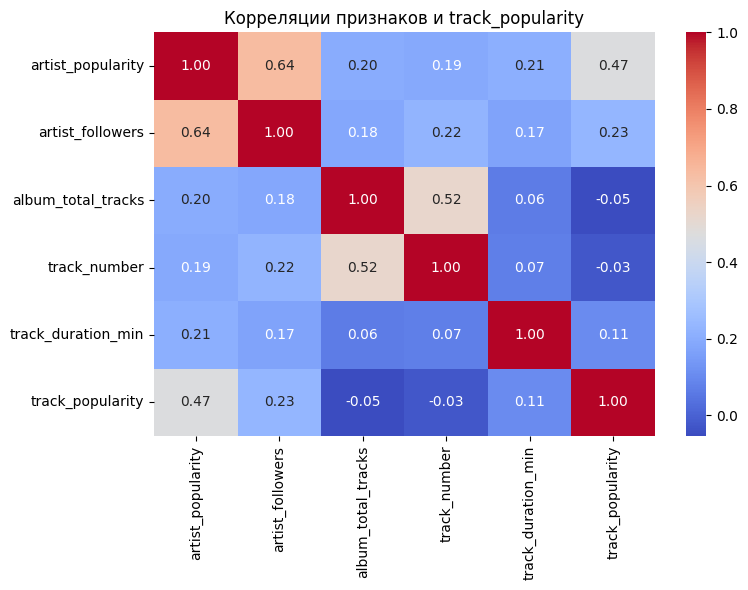

track_popularity      1.000000
artist_popularity     0.466903
artist_followers      0.232019
track_duration_min    0.105560
track_number         -0.028513
album_total_tracks   -0.053461
Name: track_popularity, dtype: float64

In [32]:
corr = df_model.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляции признаков и track_popularity")
plt.tight_layout()
plt.show()

corr[target].sort_values(ascending=False)


In [ ]:
"""
artist_popularity имеет наибольшую положительную корреляцию с 
track_popularity (~0.47), то есть чем популярнее артист, тем, 
как правило, популярнее его треки.

artist_followers слабо, но тоже положительно связан с 
популярностью трека (~0.23): больше подписчиков — в среднем 
немного выше popularity.

Остальные признаки (album_total_tracks, track_number, track_duration_min) 
почти не коррелируют с track_popularity (корреляция по модулю < 0.1), 
их влияние значительно слабее.
"""

In [ ]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def train_and_eval(features):
    model = LinearRegression()
    model.fit(X_train[features], y_train)
    
    y_pred = model.predict(X_test[features])
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"Признаки: {features}")
    print(f"R^2:  {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print("-" * 40)
    
    return model


In [34]:
# Модель 1: только популярность артиста
model_1 = train_and_eval(["artist_popularity"])

# Модель 2: добавляем число подписчиков
model_2 = train_and_eval(["artist_popularity", "artist_followers"])

# Модель 3: добавляем параметры альбома и трека
model_3 = train_and_eval([
    "artist_popularity",
    "artist_followers",
    "album_total_tracks",
    "track_number",
    "track_duration_min"
])


Признаки: ['artist_popularity']
R^2:  0.241
RMSE: 21.237
----------------------------------------
Признаки: ['artist_popularity', 'artist_followers']
R^2:  0.247
RMSE: 21.157
----------------------------------------
Признаки: ['artist_popularity', 'artist_followers', 'album_total_tracks', 'track_number', 'track_duration_min']
R^2:  0.273
RMSE: 20.783
----------------------------------------


In [ ]:
"""
Уже один признак artist_popularity даёт R² ≈ 0.24, то есть объясняет около 24% 
разброса track_popularity.

Добавление artist_followers почти не улучшает качество (R² остаётся ≈ 0.247), 
значит число подписчиков несёт мало новой информации по сравнению с самой популярностью артиста.

Подключение остальных признаков (album_total_tracks, track_number, track_duration_min) 
даёт небольшой рост R² до ≈ 0.273 и уменьшение RMSE, то есть они улучшают модель, но их вклад относительно небольшой.
"""

4. Интерпретируйте результаты моделирования (что значит полученная формула,
какие переменные вносят больший вклад).

In [40]:
final_features = [
    "artist_popularity",
    "artist_followers",
    "album_total_tracks",
    "track_number",
    "track_duration_min"
]

final_model = LinearRegression()
final_model.fit(X_train[final_features], y_train)

coef_df = pd.DataFrame({
    "feature": final_features,
    "coefficient": final_model.coef_
})
display(coef_df)

print("intercept:", final_model.intercept_)


,feature,coefficient
0,artist_popularity,6.677421e-01
1,artist_followers,-5.902421e-08
2,album_total_tracks,-2.439806e-01
3,track_number,-1.831398e-01
4,track_duration_min,5.369308e-01


intercept: 9.76054261666669


In [ ]:
"""
Наибольший вклад в популярность трека вносит artist_popularity: 
увеличение популярности артиста на 1 пункт увеличивает ожидаемую 
track_popularity примерно на 0.67 пункта.

track_duration_min тоже влияет заметно: более длинные треки в среднем 
немного популярнее (около +0.54 за каждую дополнительную минуту).

Отрицательные коэффициенты у album_total_tracks и track_number означают, 
что треки с большими номерами и в очень длинных альбомах чуть менее 
популярны. Эффект небольшой, но направлен вниз.

Коэффициент при artist_followers практически нулевой, значит число подписчиков 
почти не даёт дополнительной информации сверх artist_popularity и может 
считаться малозначимым признаком.
"""

5. Спрогнозируйте несколько новых значений с помощью построенной модели.

In [42]:
new_tracks = pd.DataFrame([
    {
        "artist_popularity": 80,
        "artist_followers": 2_000_000,
        "album_total_tracks": 12,
        "track_number": 1,
        "track_duration_min": 3.2
    },
    {
        "artist_popularity": 40,
        "artist_followers": 50_000,
        "album_total_tracks": 20,
        "track_number": 15,
        "track_duration_min": 2.1
    }
])

pred_pop = final_model.predict(new_tracks[final_features])
pred_pop

# Ожидаемая популярность


array([61.66913371, 29.96812127])

№6 (3 балла)
Различные метрики качества реализованы в пакете sklearn.metrics. Подробнее о них
смотрите в лекции или в учебных пособиях, например, https://github.com/esokolov/mlcourse-msu/blob/master/ML15/lecture-notes/Sem05_metrics.pdf.
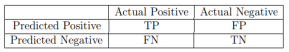

1. Загрузите файл classification.csv (https://cloud.mail.ru/public/QGde/JFrAntvih). В нем
записаны истинные классы объектов выборки (колонка true) и ответы некоторого
классификатора (колонка predicted).

In [43]:
df = pd.read_csv('classification.csv')
df = df.drop(columns=['Unnamed: 2'])
y_true = df['true']
y_pred = df['pred']
df.head()

,true,pred
0,1,0
1,1,1
2,1,1
3,0,0
4,1,1


2. Заполните таблицу ошибок классификации:<br/>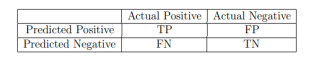<br/>
Для этого подсчитайте величины TP, FP, FN и TN согласно их определениям.
Например, FP — это количество объектов, имеющих класс 0, но отнесенных
алгоритмом к классу 1.

In [44]:
tp = np.sum((y_true == 1) & (y_pred == 1))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))
tn = np.sum((y_true == 0) & (y_pred == 0))

print('TP =', tp)
print('FP =', fp)
print('FN =', fn)
print('TN =', tn)

conf_table = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=['Predicted Positive', 'Predicted Negative'],
    columns=['Actual Positive', 'Actual Negative']
)
print(conf_table)

TP = 43
FP = 34
FN = 59
TN = 64
                    Actual Positive  Actual Negative
Predicted Positive               43               34
Predicted Negative               59               64


In [ ]:
"""
TP = 43: алгоритм правильно нашёл 43 объекта положительного класса.

TN = 64: правильно отнёс к отрицательному классу 64 объекта.

FP = 34: 34 объекта с истинным классом 0 ошибочно помечены как 1 (ложные срабатывания, “ложная тревога”).

FN = 59: 59 объектов с истинным классом 1 классификатор пропустил и отнёс к 0 (ложные пропуски).

Из этого видно, что модель чаще ошибается, пропуская положительный класс (FN больше TP), 
чем давая ложную тревогу, то есть чувствительность к классу 1 невысокая. 
"""

3. Посчитайте основные метрики качества классификатора:
a. Accuracy (доля верно угаданных) — sklearn.metrics.accuracy
b. Precision (точность) — sklearn.metrics.accuracy.precision_score
c. Recall (полнота) — sklearn.metrics.recall_score
d. F-мера — sklearn.metrics.f1_score

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print('Accuracy =', accuracy)
print('Precision =', precision)
print('Recall =', recall)
print('F1-score =', f1)


Accuracy = 0.535
Precision = 0.5584415584415584
Recall = 0.4215686274509804
F1-score = 0.48044692737430167


In [ ]:
"""
Accuracy = 0.535. Классификатор правильно определяет класс примерно у 53.5% объектов, 
то есть работает чуть лучше случайного угадывания для двух классов, но общий уровень 
качества невысокий.​​

Precision = 0.558. Среди объектов, которые алгоритм пометил как положительные, 
около 55.8% действительно относятся к положительному классу; то есть каждое второе 
“срабатывание” оказывается ложным.

Recall = 0.422. Из всех реально положительных объектов алгоритм находит только 42.2%, 
остальные он пропускает и относит к отрицательному классу, что говорит о низкой чувствительности.

F1-score = 0.48. Сводная метрика, учитывающая и precision, и recall, показывает, 
что баланс между ними средний: модель одновременно не очень точна и не очень полно 
обнаруживает положительный класс.
"""

№7 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
логистической регрессии (задача классификации). Выполните следующие действия:

1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе, как можно будет использовать полученные результаты классификации.

In [ ]:
"""
Набор содержит транзакции по кредитным картам европейских пользователей за 2 дня в сентябре 2013 года.

Time: Секунды с начала сбора данных.
V1...V28: Анонимизированные признаки (результат PCA-преобразования), так как реальные данные (имя, адрес и т.д.) конфиденциальны.
Amount: Сумма транзакции.
Class: Целевая переменная (0 — обычная транзакция, 1 — мошенничество).

Модель поможет банку блокировать подозрительные операции в реальном времени, минимизируя финансовые потери.
"""

2. Постройте классификацию, используя логистическую регрессионную модель.
Оцените качество работы модели.

In [147]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Загрузка данных
df = pd.read_csv('creditcard.csv')

# Подготовка
# Удаляем Class (ответ) и Time 
# не несет пользы для простой модели
X = df.drop(['Class'], axis=1) 
if 'Time' in df.columns: X = X.drop(['Time'], axis=1)
y = df['Class']

# Разбиваем на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабируем 'Amount'
# для Логистической регрессии
scaler = StandardScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

# Обучение модели
# class_weight='balanced' 
# для поиска редких мошенников
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Оценка качества
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))



              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [ ]:
"""
Recall (Полнота) для Fraud = 0.92: Модель обнаружила 92% всех мошенников. Это неплохой результат для базовой модели

Precision (Точность) для Fraud = 0.06: Низкая точность означает, что модель часто тревожится понапрасну (ложные срабатывания)
В банковской сфере это допустимо: лучше проверить клиента звонком, чем пропустить кражу
"""

3. Спрогнозируйте несколько новых значений с помощью построенной модели.

In [ ]:
"""
Спрогнозируем статус двух новых транзакций: обычной ($50, стандартные параметры) 
и подозрительной ($5000, аномальные параметры)
"""

In [ ]:
# Создаем новые примеры (V1-V28 + Amount)
# Обычные значения (близки к 0) и сумма $50
new_normal = np.zeros((1, 29)) 
new_normal[0, -1] = 50.0 

# Аномальные значения (шум) и сумма $5000
new_fraud = np.random.uniform(2, 5, (1, 29)) 
new_fraud[0, -1] = 5000.0

# Собираем в DataFrame
cols = [f'V{i}' for i in range(1, 29)] + ['Amount']
new_data = pd.DataFrame(np.vstack([new_normal, new_fraud]), columns=cols)

# Масштабируем Amount тем же скейлером
new_data['Amount'] = scaler.transform(new_data[['Amount']])

# Прогноз
preds = model.predict(new_data)
probs = model.predict_proba(new_data)

print(f"Прогноз классов: {preds}") 
# 0 = Норма, 1 = Мошенничество
print(f"Вероятность мошенничества: {probs[:, 1]}")


Прогноз классов: [0 1]
Вероятность мошенничества: [0.02243945 1.        ]


In [ ]:
"""
Транзакция 1: Класс 0 (Норма). Вероятность мошенничества низкая.
Транзакция 2: Класс 1 (Мошенничество). Вероятность близка к 100% 
из-за аномальных значений V-признаков и огромной суммы.
"""